In [2]:
!pip install fastlowess

Head des données :
   times  accel
0    2.4    0.0
1    2.6   -1.3
2    3.2   -2.7
3    3.6    0.0
4    4.0   -2.7
5    6.2   -2.7
6    6.6   -2.7
7    6.8   -1.3
8    7.8   -2.7
9    8.2   -2.7

Description statistique :
            times       accel
count  133.000000  133.000000
mean    25.178947  -25.545865
std     13.132063   48.322050
min      2.400000 -134.000000
25%     15.600000  -54.900000
50%     23.400000  -13.300000
75%     34.800000    0.000000
max     57.600000   75.000000

Shape : (133, 2)


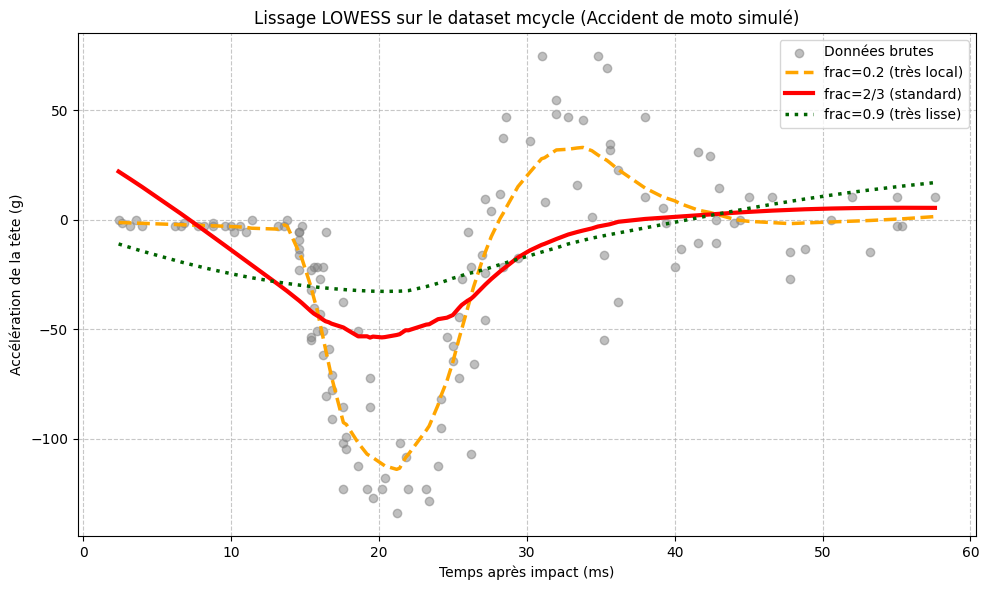

In [3]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Charger le dataset 
mcycle = sm.datasets.get_rdataset("mcycle", "MASS").data

# Aperçu rapide des données
print("Head des données :")
print(mcycle.head(10))
print("\nDescription statistique :")
print(mcycle.describe())
print("\nShape :", mcycle.shape)

# Plot de base avec scatter
plt.figure(figsize=(10, 6))
plt.scatter(mcycle['times'], mcycle['accel'], alpha=0.5, color='grey', label='Données brutes')

# Appliquer LOWESS avec différents fractions
lowess_02 = sm.nonparametric.lowess(mcycle['accel'], mcycle['times'], frac=0.2)
lowess_066 = sm.nonparametric.lowess(mcycle['accel'], mcycle['times'], frac=2/3)
lowess_09 = sm.nonparametric.lowess(mcycle['accel'], mcycle['times'], frac=0.9)

# Ajouter les courbes
plt.plot(lowess_02[:, 0], lowess_02[:, 1], color='orange', linewidth=2.5, linestyle='--', label='frac=0.2 (très local)')
plt.plot(lowess_066[:, 0], lowess_066[:, 1], color='red', linewidth=3, label='frac=2/3 (standard)')
plt.plot(lowess_09[:, 0], lowess_09[:, 1], color='darkgreen', linewidth=2.5, linestyle=':', label='frac=0.9 (très lisse)')

# Labels et titre
plt.title("Lissage LOWESS sur le dataset mcycle (Accident de moto simulé)")
plt.xlabel("Temps après impact (ms)")
plt.ylabel("Accélération de la tête (g)")
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [4]:
import fastlowess as fl
x = mcycle['times'].values
y = mcycle['accel'].values


AIC:           None
AICc:          None
R²:            0.7986135349916546
MAE:           14.189863432322438
RMSE:          21.603376589257472
Effective df:  None
CV scores:     [30.55254796 34.0698615  36.80848147 41.69400966 47.35532774 52.62305375
 54.51213372 53.07459323 51.06710056 48.92110077]


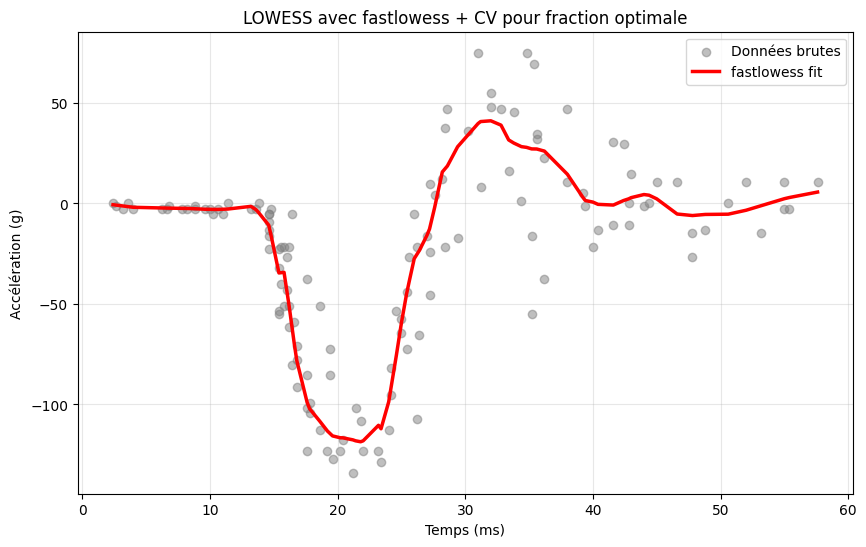

In [5]:
import numpy as np

# Création du modèle AVEC les configs CV + diagnostics
model = fl.Lowess(
    return_diagnostics=True,          
    cv_fractions= np.linspace(0.1, 0.9, 10),
    cv_method="kfold",                
    cv_k=5,                          
    iterations=3,                  
    parallel=True,                 
)

# Fit : seulement x et y ici !
result = model.fit(x, y)

# Accès aux résultats
diag = result.diagnostics

# Affichage des métriques (si diagnostics activés)
if diag is not None:
    print("AIC:          ", diag.aic)
    print("AICc:         ", diag.aicc)
    print("R²:           ", diag.r_squared)
    print("MAE:          ", diag.mae)
    print("RMSE:         ", diag.rmse)
    print("Effective df: ", diag.effective_df)
else:
    print("Diagnostics non disponibles – vérifie return_diagnostics=True")

# Scores de cross-validation (meilleure fraction, scores par fold, etc.)
print("CV scores:    ", result.cv_scores)   # Souvent un dict ou liste avec scores par fraction

# Plot du lissage
plt.figure(figsize=(10, 6))
plt.scatter(x, y, alpha=0.5, color='grey', label='Données brutes')
plt.plot(result.x, result.y, color='red', linewidth=2.5, label='fastlowess fit')
plt.xlabel("Temps (ms)")
plt.ylabel("Accélération (g)")
plt.title("LOWESS avec fastlowess + CV pour fraction optimale")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()